<a href="https://colab.research.google.com/github/MabelSSantos/GEDI_start/blob/main/4_GEDI_Pairs_NDVI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GEDI Extracting NDVI

In [ ]:
import geemap
import pandas as pd
import ee
import geopandas as gpd
import math
import time
import seaborn as sns
import matplotlib.pyplot as plt
from shapely import wkt
from google.colab import drive
from pathlib import Path


In [ ]:
# Install deps
!pip -q install earthengine-api geemap geopandas


In [ ]:
ee.Authenticate()
ee.Initialize(project='instant-pivot-489802-p0')

In [ ]:
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
#Input and output paths

pre_path = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_25_pairs_pre.geojson")
post_path = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_25_pairs_post.geojson")
tmp_dir = Path("/content/sample_data/Pair_footprints/chunks")
tmp_dir.mkdir(parents=True, exist_ok=True)

pairs_path = Path("/content/drive/MyDrive/GEDI/Gedidb/GEDI_25_Footprint_Pairs_Fire_FF_FYs.gpkg")
ndvi_csv_path = Path("/content/drive/MyDrive/GEE_exports/GEDI_25_pairs_preFire_NDVI_all_chunks_merged.csv")

out_gpkg = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_25_Footprint_Fire_Pairs_FF_FYs_NDVI.gpkg")
out_csv = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_Footprint_Fire_Pairs_FF_FYs_NDVI.csv")


In [ ]:
print(pairs.columns)

Index(['index_1', 'index_2', 'distance_m', 'fire', 'time_1', 'fire_date',
       'time_2', 'season', 'fire_frequency', 'fire_years', 'pre_veg_age',
       'post_fire_months', 'agbd_1', 'agbd_2', 'delta_agbd', 'rh_98_1',
       'rh_98_2', 'rh_90_1', 'rh_90_2', 'rh_50_1', 'rh_50_2', 'cover_1',
       'cover_2', 'pai_1', 'pai_2', 'wsci_1', 'wsci_2', 'agbd_pi_lower_1',
       'agbd_pi_upper_1', 'agbd_se_1', 'agbd_pi_lower_2', 'agbd_pi_upper_2',
       'agbd_se_2', 'img_date', 'ndvi_1', 'ndvi_2', 'delta_ndvi',
       'delta_ndvi_abs', 'pair_uid', 'subregion', 'gedi_point_wkt_1',
       'gedi_point_wkt_2', 'pairing_crs', 'geometry_crs_1', 'geometry_crs_2',
       'shot_number_1', 'shot_number_2', 'geometry_1', 'geometry_2',
       'geometry'],
      dtype='object')


In [ ]:
#Loading pre and post footprints

pre = gpd.read_file(pre_path)
post = gpd.read_file(post_path)

# keep only common ids
ids = set(pre["pair_uid"]).intersection(set(post["pair_uid"]))
pre = pre[pre["pair_uid"].isin(ids)].copy()
post = post[post["pair_uid"].isin(ids)].copy()

pre = pre.sort_values("pair_uid")
post = post.sort_values("pair_uid")

print(len(pre), len(post))

595 595


In [ ]:
# NDVI function (Gedi footprint = 25 m => Diameter/ Geolocation error = 10.2 m => from the point (added to the radius) //// GEDI buffer = 22.7 m => Radius)

BUFFER_M = 30
DAYS_WINDOW = 45
MAX_CLOUD = 30
SCALE = 10
NDVI_BIN_FACTOR = 50

def mask_s2_qa60(img):
    qa = img.select("QA60")
    cloud = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return img.updateMask(mask).copyProperties(img, ["system:time_start"])

def add_ndvi_at_date1(feat):
    date1 = ee.Date(feat.get("date_1"))
    geom = feat.geometry().buffer(BUFFER_M)

    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(geom)
           .filterDate(date1.advance(-DAYS_WINDOW, "day"), date1.advance(DAYS_WINDOW + 1, "day"))
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .map(mask_s2_qa60)
           .map(lambda img: img.set("time_diff", ee.Number(img.date().millis()).subtract(date1.millis()).abs())))

    fallback = ee.Image.constant([0, 0]).rename(["B8", "B4"]).updateMask(ee.Image.constant(0)).set("system:time_start", date1.millis())
    closest = ee.Image(ee.Algorithms.If(col.size().gt(0), col.sort("time_diff").first(), fallback))

    ndvi = closest.normalizedDifference(["B8", "B4"]).rename("NDVI")

    med = ndvi.reduceRegion(
        reducer=ee.Reducer.median(),
        geometry=geom,
        scale=SCALE,
        bestEffort=True,
        maxPixels=1e8
    ).get("NDVI")

    return feat.set({
        "img_date": ee.Date(closest.get("system:time_start")).format("YYYY-MM-dd"),
        "ndvi_median": med
    })


def add_diff(f):
    pre_v = ee.Number(f.get("ndvi_median_pregeom_at_date1"))
    post_v = ee.Number(f.get("ndvi_median_postgeom_at_date1"))
    d = post_v.subtract(pre_v)
    return f.set({
        "ndvi_pre_condition_diff": d,
        "ndvi_pre_condition_abs_diff": d.abs()
    })



In [ ]:
CHUNK_SIZE = 800
folder = "GEE_exports"

uids = pre["pair_uid"].tolist()
tasks = []

for i in range(0, len(uids), CHUNK_SIZE):
    chunk_ids = set(uids[i:i+CHUNK_SIZE])
    cpre = pre[pre["pair_uid"].isin(chunk_ids)]
    cpost = post[post["pair_uid"].isin(chunk_ids)]

    pre_chunk_file = tmp_dir / f"pre_{i:05d}.geojson"
    post_chunk_file = tmp_dir / f"post_{i:05d}.geojson"
    cpre.to_file(pre_chunk_file, driver="GeoJSON")
    cpost.to_file(post_chunk_file, driver="GeoJSON")

    pre_fc = geemap.geojson_to_ee(str(pre_chunk_file))
    post_fc = geemap.geojson_to_ee(str(post_chunk_file))

    pre_out = pre_fc.map(add_ndvi_at_date1).select(["pair_uid","date_1","img_date","ndvi_median"])
    post_out = post_fc.map(add_ndvi_at_date1).select(["pair_uid","date_1","img_date","ndvi_median"])

    joined = ee.Join.inner().apply(
        pre_out, post_out, ee.Filter.equals(leftField="pair_uid", rightField="pair_uid")
    )

    def merge_pair(f):
        a = ee.Feature(f.get("primary"))
        b = ee.Feature(f.get("secondary"))
        return ee.Feature(None, {
            "pair_uid": a.get("pair_uid"),
            "date_1": a.get("date_1"),
            "pre_img_date": a.get("img_date"),
            "post_img_date": b.get("img_date"),
            "ndvi_median_pregeom_at_date1": a.get("ndvi_median"),
            "ndvi_median_postgeom_at_date1": b.get("ndvi_median")
        })

    pairs_ndvi = ee.FeatureCollection(joined.map(merge_pair))
    pairs_ndvi = pairs_ndvi.filter(ee.Filter.notNull(["ndvi_median_pregeom_at_date1", "ndvi_median_postgeom_at_date1"]))
    pairs_ndvi = pairs_ndvi.map(add_diff)

    name = f"GEDI_pairs_NDVI_chunk_{i:05d}"
    task = ee.batch.Export.table.toDrive(
        collection=pairs_ndvi,
        description=name,
        folder=folder,
        fileNamePrefix=name,
        fileFormat="CSV"
    )
    task.start()
    tasks.append(task)
    print("Started:", name)

print("Total tasks:", len(tasks))


Started: GEDI_pairs_NDVI_chunk_00000
Total tasks: 1


In [ ]:
# Check task status
for t in tasks:
    s = t.status()
    print(s.get("description"), s.get("state"))


GEDI_pairs_NDVI_chunk_00000 READY


In [ ]:
while True:
    states = {}
    for t in tasks:
        st = t.status().get("state")
        states[st] = states.get(st, 0) + 1

    print(states)
    if states.get("RUNNING", 0) == 0 and states.get("READY", 0) == 0:
        break

    time.sleep(60)


{'FAILED': 1}


#Run 1
BUFFER_M = 17.6 m
DAYS_WINDOW = 30
MAX_CLOUD = 40
SCALE = 10
NDVI_BIN_FACTOR = 50

Non null rows: 20019 / Out of 22280
Run time ~ 6 hours

#Run 2
BUFFER_M = 20 m
DAYS_WINDOW = 15
MAX_CLOUD = 30
SCALE = 10
NDVI_BIN_FACTOR = 50

Non null rows: 19671 / Out of 22280
Run time ~ 5 hours


In [ ]:
export_dir = Path("/content/drive/MyDrive/GEE_exports")
print("Exists:", export_dir.exists())
print("Sample files:")
for p in list(export_dir.glob("*.csv"))[:20]:
    print(p.name)

Exists: True
Sample files:
GEDI_pre_NDVI.csv
GEDI_post_NDVI.csv


In [ ]:
print(Path('/content/drive/MyDrive').exists())

True


In [ ]:
export_dir = Path("/content/drive/MyDrive/GEE_exports")

# Match both original and duplicated names
files = sorted(export_dir.glob("GEDI_pairs_NDVI_chunk_*.csv"))
print("Matched:", len(files))

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df = df.sort_values("pair_uid").drop_duplicates(subset=["pair_uid"], keep="first")

out_csv = export_dir / "GEDI_pairs_preFire_NDVI_all_chunks_merged.csv"
df.to_csv(out_csv, index=False)

print("Saved:", out_csv)
print("Rows:", len(df))


Matched: 0


ValueError: No objects to concatenate

In [ ]:

# Correcting the path for pairs_path
pairs_path = Path("/content/drive/MyDrive/GEDI/GEDIdb/GEDI_Footprint_Pairs_Fire_FF_FYs.gpkg")

#Read total Pairs data
pairs = gpd.read_file(pairs_path)
ndvi = pd.read_csv(ndvi_csv_path)

print("pairs rows:", len(pairs))
print("ndvi rows :", len(ndvi))

pairs rows: 6502
ndvi rows : 5851


In [ ]:
# Merging NDVI with Pairs

if "pair_uid" not in pairs.columns:
    pairs["pair_uid"] = range(len(pairs))

pairs["pair_uid"] = pd.to_numeric(pairs["pair_uid"], errors="coerce").astype("Int64")
ndvi["pair_uid"] = pd.to_numeric(ndvi["pair_uid"], errors="coerce").astype("Int64")

# keep only NDVI columns you want
ndvi_cols = [
    "pair_uid",
    "pre_img_date", "post_img_date",
    "ndvi_median_pregeom_at_date1", "ndvi_median_postgeom_at_date1",
    "ndvi_pre_condition_diff", "ndvi_pre_condition_abs_diff"
]
ndvi_cols = [c for c in ndvi_cols if c in ndvi.columns]
ndvi_sub = ndvi[ndvi_cols].drop_duplicates(subset=["pair_uid"])


In [ ]:
# Merge
pairs_ndvi = pairs.merge(ndvi_sub, on="pair_uid", how="left")

print("merged rows:", len(pairs_ndvi))
print("rows with NDVI diff:", pairs_ndvi["ndvi_pre_condition_diff"].notna().sum())
print("rows without NDVI diff:", pairs_ndvi["ndvi_pre_condition_diff"].isna().sum())


merged rows: 6502
rows with NDVI diff: 5851
rows without NDVI diff: 651


In [ ]:
# Save outputs
pairs_ndvi.to_file(out_gpkg, driver="GPKG")
pairs_ndvi.drop(columns="geometry", errors="ignore").to_csv(out_csv, index=False)

print("Saved GPKG:", out_gpkg)
print("Saved CSV :", out_csv)


Saved GPKG: /content/drive/MyDrive/GEDI/GEDIdb/GEDI_Footprint_Fire_Pairs_FF_FYs_NDVI.gpkg
Saved CSV : /content/drive/MyDrive/GEE_exports/GEDI_pairs_preFire_NDVI_all_chunks_merged.csv


In [ ]:
path = "/content/drive/MyDrive/GEDI/GEDIdb/GEDI_Footprint_Fire_Pairs_FF_FYs_NDVI.gpkg"
pairs = gpd.read_file(path)
print(pairs.columns.tolist())


['index_1', 'index_2', 'distance_m', 'fire', 'time_1', 'fire_date', 'time_2', 'fire_frequency', 'fire_years', 'pre_veg_age', 'post_fire_months', 'agbd_1', 'agbd_2', 'delta_agbd', 'rh_98_1', 'rh_98_2', 'rh_90_1', 'rh_90_2', 'rh_50_1', 'rh_50_2', 'cover_1', 'cover_2', 'pai_1', 'pai_2', 'wsci_1', 'wsci_2', 'agbd_pi_lower_1', 'agbd_pi_upper_1', 'agbd_se_1', 'agbd_pi_lower_2', 'agbd_pi_upper_2', 'agbd_se_2', 'pair_uid', 'gedi_point_wkt_1', 'gedi_point_wkt_2', 'pairing_crs', 'geometry_crs_1', 'geometry_crs_2', 'shot_number_1', 'shot_number_2', 'geometry_1', 'geometry_2', 'pre_img_date', 'post_img_date', 'ndvi_median_pregeom_at_date1', 'ndvi_median_postgeom_at_date1', 'ndvi_pre_condition_diff', 'ndvi_pre_condition_abs_diff', 'geometry']


In [ ]:
len(pairs)

6502

In [ ]:
# Convert to datetime
pairs['time_1'] = pd.to_datetime(pairs['time_1'])
pairs['time_2'] = pd.to_datetime(pairs['time_2'])

dry_months = [7, 8, 9, 10, 11]

def classify_season(dt):
    return "dry" if dt.month in dry_months else "wet"

pairs['season_1'] = pairs['time_1'].apply(classify_season)
pairs['season_2'] = pairs['time_2'].apply(classify_season)

#Seasons in
pairs['season'] = pairs.apply(
    lambda row: "same" if row['season_1'] == row['season_2'] else "different",
    axis=1
)


In [ ]:
pairs_same=pairs[pairs['season']=='same']

len(pairs_same)

3880

In [ ]:
pairs.head()

,index_1,index_2,distance_m,fire,time_1,fire_date,time_2,fire_frequency,fire_years,pre_veg_age,...,pre_img_date,post_img_date,ndvi_median_pregeom_at_date1,ndvi_median_postgeom_at_date1,ndvi_pre_condition_diff,ndvi_pre_condition_abs_diff,geometry,season_1,season_2,season
0,15746,15747,3.030845,True,2020-04-21,2020-07-01 00:00:00,2022-04-08,2,"2020,2022",NaN,...,None,None,NaN,NaN,NaN,NaN,"LINESTRING (-51.04574 -4.22884, -51.04577 -4.2...",wet,wet,same
1,7437,7438,3.827840,True,2020-09-21,2022-09-01 00:00:00,2023-01-30,4,"1999,2014,2018,2022",2.0,...,2020-09-17,2020-09-17,0.802664,0.799447,-0.003217,0.003217,"LINESTRING (-49.64328 -4.82409, -49.64327 -4.8...",dry,wet,different
2,7439,7440,3.939691,True,2020-09-21,2022-09-01 00:00:00,2023-01-30,1,2022,NaN,...,2020-09-17,2020-09-17,0.836764,0.838967,0.002203,0.002203,"LINESTRING (-49.64358 -4.82367, -49.64357 -4.8...",dry,wet,different
3,32267,32268,4.106089,True,2020-08-09,2020-10-01 00:00:00,2021-09-24,4,"2020,2021,2022,2023",NaN,...,2020-08-06,2020-08-06,0.807259,0.805147,-0.002112,0.002112,"LINESTRING (-50.52181 -3.56472, -50.52178 -3.5...",dry,dry,same
4,9379,9378,4.224179,True,2019-08-28,2020-11-01 00:00:00,2022-08-20,2,"2020,2022",NaN,...,2019-08-24,2019-08-24,0.852996,0.853192,0.000196,0.000196,"LINESTRING (-49.66268 -4.46282, -49.66271 -4.4...",dry,dry,same


In [ ]:
print(pairs.columns)

Index(['index_1', 'index_2', 'distance_m', 'fire', 'time_1', 'fire_date',
       'time_2', 'fire_frequency', 'fire_years', 'pre_veg_age',
       'post_fire_months', 'agbd_1', 'agbd_2', 'delta_agbd', 'rh_98_1',
       'rh_98_2', 'rh_90_1', 'rh_90_2', 'rh_50_1', 'rh_50_2', 'cover_1',
       'cover_2', 'pai_1', 'pai_2', 'wsci_1', 'wsci_2', 'agbd_pi_lower_1',
       'agbd_pi_upper_1', 'agbd_se_1', 'agbd_pi_lower_2', 'agbd_pi_upper_2',
       'agbd_se_2', 'pair_uid', 'gedi_point_wkt_1', 'gedi_point_wkt_2',
       'pairing_crs', 'geometry_crs_1', 'geometry_crs_2', 'shot_number_1',
       'shot_number_2', 'geometry_1', 'geometry_2', 'pre_img_date',
       'post_img_date', 'ndvi_median_pregeom_at_date1',
       'ndvi_median_postgeom_at_date1', 'ndvi_pre_condition_diff',
       'ndvi_pre_condition_abs_diff', 'geometry', 'season_1', 'season_2',
       'season'],
      dtype='object')


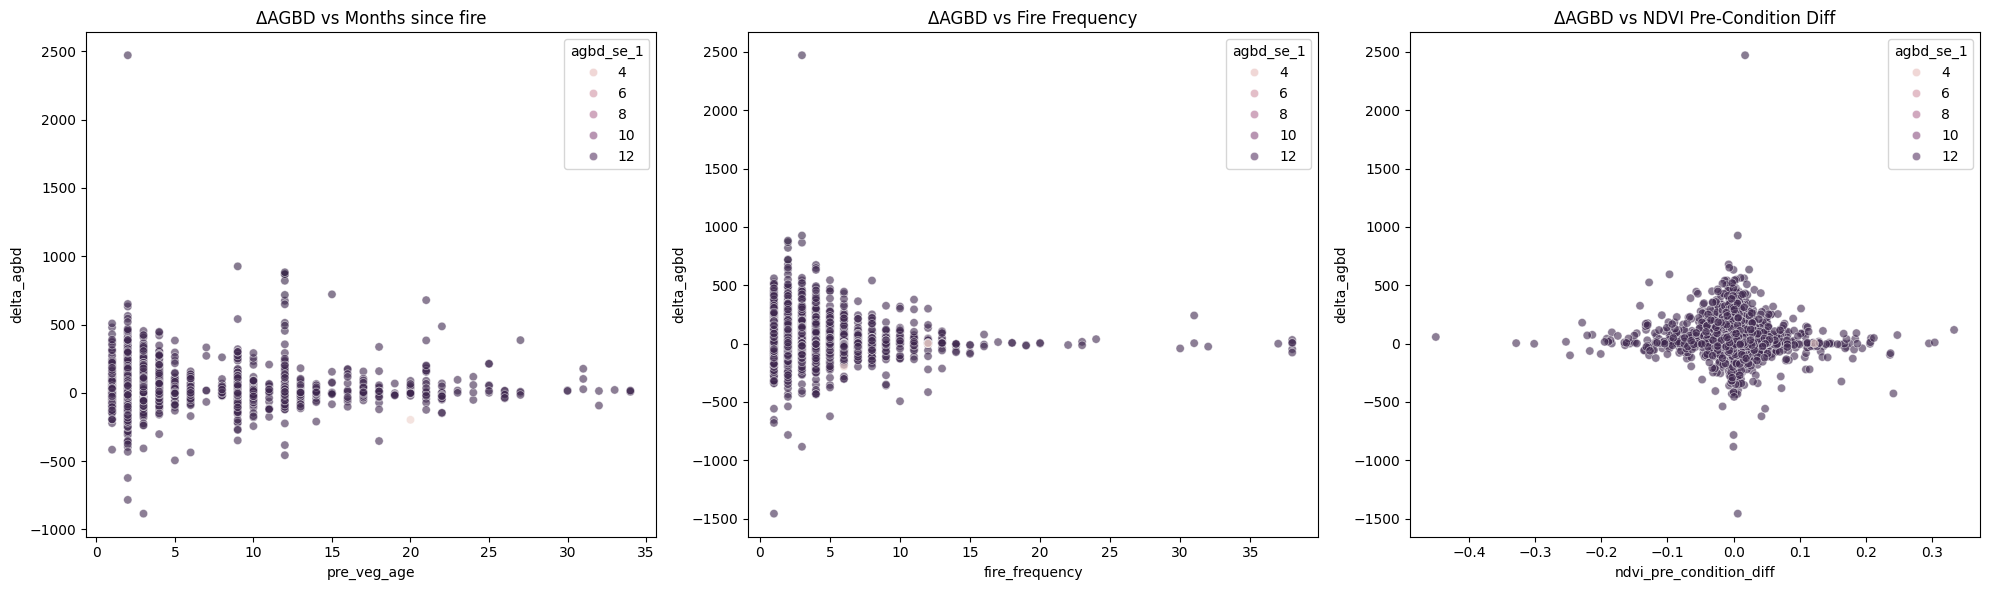

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(
    data=pairs_same, x='pre_veg_age', y='delta_agbd',
    hue='agbd_se_1', alpha=0.6, ax=axes[0]
)
axes[0].set_title("ΔAGBD vs Months since fire")

sns.scatterplot(
    data=pairs_same, x='fire_frequency', y='delta_agbd',
    hue='agbd_se_1', alpha=0.6, ax=axes[1]
)
axes[1].set_title("ΔAGBD vs Fire Frequency")

sns.scatterplot(
    data=pairs_same, x='ndvi_pre_condition_diff', y='delta_agbd',
    hue='agbd_se_1', alpha=0.6, ax=axes[2]
)
axes[2].set_title("ΔAGBD vs NDVI Pre-Condition Diff")

plt.tight_layout()
plt.show()


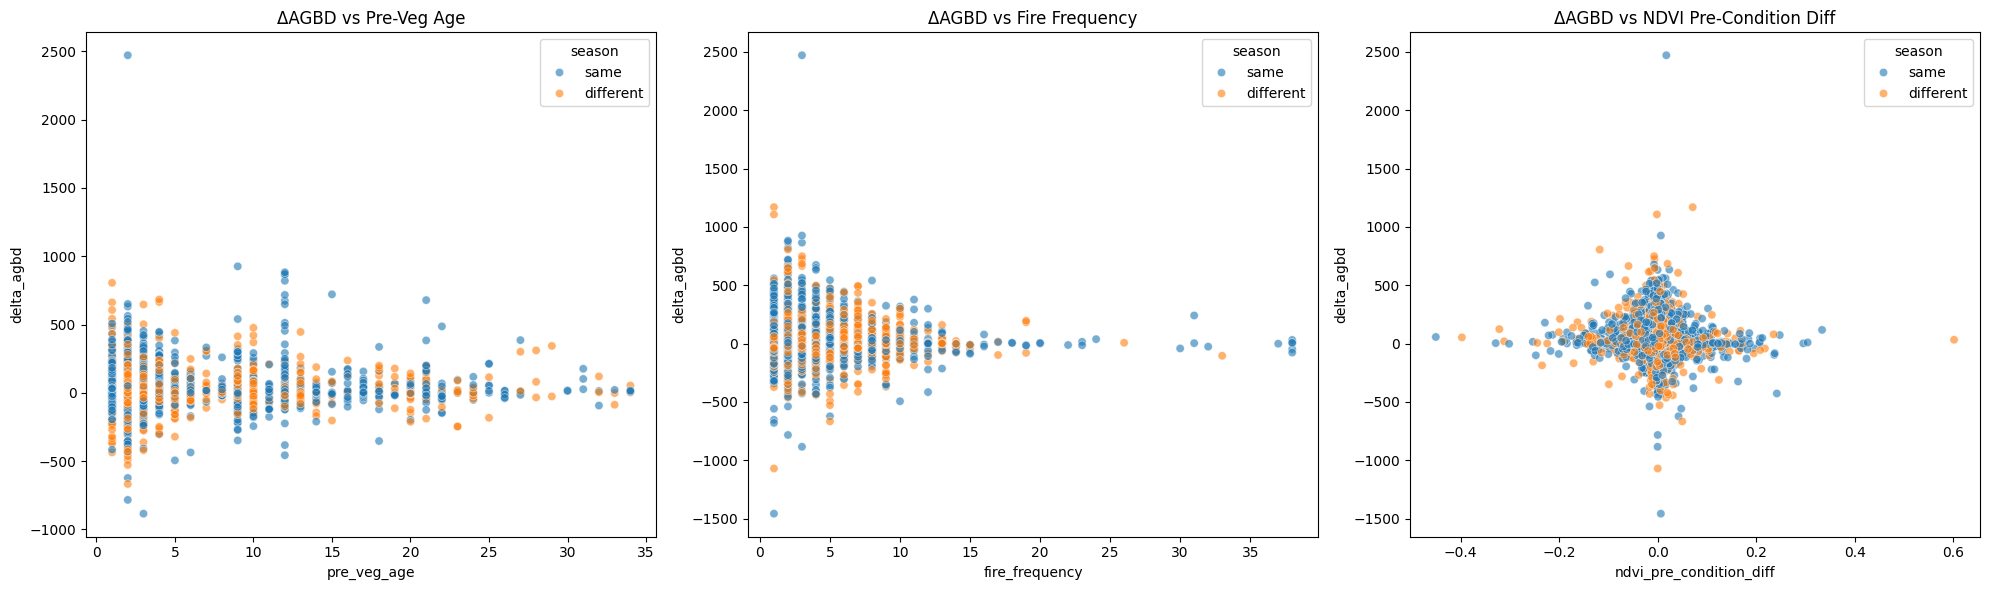

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(
    data=pairs, x='pre_veg_age', y='delta_agbd',
    hue='season', alpha=0.6, ax=axes[0]
)
axes[0].set_title("ΔAGBD vs Pre-Veg Age")

sns.scatterplot(
    data=pairs, x='fire_frequency', y='delta_agbd',
    hue='season', alpha=0.6, ax=axes[1]
)
axes[1].set_title("ΔAGBD vs Fire Frequency")

sns.scatterplot(
    data=pairs, x='ndvi_pre_condition_diff', y='delta_agbd',
    hue='season', alpha=0.6, ax=axes[2]
)
axes[2].set_title("ΔAGBD vs NDVI Pre-Condition Diff")

plt.tight_layout()
plt.show()
